In [17]:
! pip install langchain langchain-community langgraph python-dotenv faiss-cpu pypdf langchain_text_splitters langchain_groq sentence-transformers langchain-core


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel

load_dotenv()

True

In [19]:
docs = (PyPDFLoader("./documents/book1.pdf").load()+ PyPDFLoader("./documents/book2.pdf").load()+PyPDFLoader("./documents/book3.pdf").load())

In [20]:
len(docs)

2123

In [21]:
#2 chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150).split_documents(docs)

#3 clean text to avoid UnicodeEncodeError (Surrogate from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8', 'ignore').decode('utf-8')

In [22]:
len(chunks)

5766

In [23]:
# 3 Embbeding 
#Embedding the chunks and store in FAISS vector store
embedding = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    encode_kwargs={"normalize_embeddings": True}
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6308.84it/s]


In [24]:
# store the embeddings in FAISS vector store
vector_store = FAISS.from_documents(chunks, embedding)

In [25]:
# Retriever the top 4 relevant chunks
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [26]:
# model for question answering
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [27]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]           # output of decompositions (sentences strips)
    kept_strips: List[str]      # the strips that are kept after relevance checking with retriever   
    refined_context:str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [28]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [29]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
           "system",
            "You are a strict relevance filter.\n"
            "Return a boolean value: use true if the sentence directly helps answer the question, false otherwise.\n"
            "Output ONLY valid JSON in this exact format: {{\"keep\": true}} or {{\"keep\": false}}\n"
            "Use literal true/false (not strings), no additional text."
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [30]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

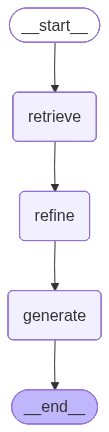

In [31]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine",refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [32]:
# 5) Run
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

* The bias-variance tradeoff refers to the trade-off between the squared bias and variance in a model.
* The squared bias represents the extent to which the average prediction over all data sets differs from the desired regression function.
* The variance measures the extent to which the solutions for individual data sets vary around their average.
* Very flexible models have low bias and high variance, while relatively rigid models have high bias and low variance.
* The goal is to minimize the expected loss, which is the sum of the squared bias, variance, and a constant noise term.
* The model with the optimal predictive capability is the one that leads to the best balance between bias and variance.


In [33]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 149
inside the braces, and then expand, we obtain
{y(x; D) − ED[y(x; D)] + ED[y(x; D)] − h(x)}2
= {y(x; D) − ED[y(x; D)]}2 + {ED[y(x; D)] − h(x)}2
+2{y(x; D) − ED[y(x; D)]}{ED[y(x; D)] − h(x)}. (3.39)
We now take the expectation of this expression with respect to D and note that the
ﬁnal term will vanish, giving
ED
[
{y(x; D) − h(x)}2]
= {ED[y(x; D)] − h(x)}2
  
(bias)2
+ ED
[
{y(x; D) − ED[y(x; D)]}2]
  
variance
. (3.40)
We see that the expected squared difference between y(x; D) and the regression
function h(x) can be expressed as the sum of two terms. The ﬁrst term, called the
squared bias, represents the extent to which the average prediction over all data sets
differs from the desired regression function. The second term, called the variance,
measures the extent to which the solutions for individual data sets vary around their
average, and hence this measures the extent to which the functiony(x; D) is sensitive
************************

In [34]:
print(res['refined_context'])

The Bias-Variance Decomposition 149 inside the braces, and then expand, we obtain {y(x; D) − ED[y(x; D)] + ED[y(x; D)] − h(x)}2 = {y(x; D) − ED[y(x; D)]}2 + {ED[y(x; D)] − h(x)}2 +2{y(x; D) − ED[y(x; D)]}{ED[y(x; D)] − h(x)}.
(3.39) We now take the expectation of this expression with respect to D and note that the ﬁnal term will vanish, giving ED [ {y(x; D) − h(x)}2] = {ED[y(x; D)] − h(x)}2    (bias)2 + ED [ {y(x; D) − ED[y(x; D)]}2]    variance .
(3.40) We see that the expected squared difference between y(x; D) and the regression function h(x) can be expressed as the sum of two terms.
The ﬁrst term, called the squared bias, represents the extent to which the average prediction over all data sets differs from the desired regression function.
The second term, called the variance, measures the extent to which the solutions for individual data sets vary around their average, and hence this measures the extent to which the functiony(x; D) is sensitive average, and hence this measu

In [35]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [36]:
decompose_to_sentences("""A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text. It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data. Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training. This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.""")

['A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text.',
 'It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data.',
 'Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training.',
 'This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.']